# Stage 01: Data Understanding

This notebook is the initial data-understanding stage for the Hillstrom dataset. Its purpose is to profile the raw data structure, variables, experimental groups, outcomes, and potential data-quality concerns. The raw file is read without modification: no cleaning, transformations, treatment-effect inference, hypothesis tests, or recommendations are performed here.

## 1. Load the raw data

The path below is project-relative. The dataset remains in `data/raw/` and is not written by this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_PATH = Path('data/raw/Hillstrom.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/raw/Hillstrom.csv')

hillstrom = pd.read_csv(DATA_PATH)
print(f'Loaded raw dataset from: {DATA_PATH}')
print(f'Dataset shape: {hillstrom.shape[0]:,} rows × {hillstrom.shape[1]} columns')

Matplotlib is building the font cache; this may take a moment.


Loaded raw dataset from: ../data/raw/Hillstrom.csv
Dataset shape: 64,000 rows × 12 columns


In [2]:
display(hillstrom.head())
display(hillstrom.tail())
display(hillstrom.sample(n=5, random_state=42))

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0
63999,1,4) $350 - $500,472.82,0,1,Surburban,0,Web,Mens E-Mail,0,0,0.0


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
33042,9,1) $0 - $100,64.85,1,0,Surburban,1,Web,Mens E-Mail,0,0,0.0
7209,1,2) $100 - $200,144.12,0,1,Urban,0,Web,Mens E-Mail,0,0,0.0
24367,1,5) $500 - $750,734.25,0,1,Surburban,1,Phone,Mens E-Mail,0,0,0.0
19599,4,"7) $1,000 +",1321.26,1,0,Surburban,1,Multichannel,Mens E-Mail,1,0,0.0
31465,2,3) $200 - $350,261.23,1,1,Surburban,1,Web,Womens E-Mail,1,0,0.0


## 2. Dataset structure

This section records the observed schema and completeness of each variable.

In [3]:
print(f'Rows: {len(hillstrom):,}')
print(f'Columns: {hillstrom.shape[1]}')
print('Column names:', hillstrom.columns.tolist())
print('\nData types:')
display(hillstrom.dtypes.rename('data_type').to_frame())
print(f'\nMemory usage (deep): {hillstrom.memory_usage(deep=True).sum():,} bytes')
print(f'Index: {hillstrom.index}')

structure_summary = pd.DataFrame({
    'column_name': hillstrom.columns,
    'data_type': hillstrom.dtypes.astype(str).to_numpy(),
    'non_null_count': hillstrom.notna().sum().to_numpy(),
    'missing_count': hillstrom.isna().sum().to_numpy(),
    'missing_percentage': (hillstrom.isna().mean() * 100).round(2).to_numpy(),
    'unique_values': hillstrom.nunique(dropna=False).to_numpy(),
})
display(structure_summary)

Rows: 64,000
Columns: 12
Column names: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']

Data types:


,data_type
recency,int64
history_segment,str
history,float64
mens,int64
womens,int64
zip_code,str
newbie,int64
channel,str
segment,str
visit,int64



Memory usage (deep): 18,947,152 bytes
Index: RangeIndex(start=0, stop=64000, step=1)


,column_name,data_type,non_null_count,missing_count,missing_percentage,unique_values
0,recency,int64,64000,0,0.0,12
1,history_segment,str,64000,0,0.0,7
2,history,float64,64000,0,0.0,34833
3,mens,int64,64000,0,0.0,2
4,womens,int64,64000,0,0.0,2
5,zip_code,str,64000,0,0.0,3
6,newbie,int64,64000,0,0.0,2
7,channel,str,64000,0,0.0,3
8,segment,str,64000,0,0.0,3
9,visit,int64,64000,0,0.0,2


## 3. Variable understanding

Integer-coded binary variables are profiled as categorical rather than continuous. `recency`, `history`, and `spend` are profiled numerically because their observed values and names suggest ordered elapsed time or monetary measures; this is a descriptive classification only.

In [4]:
categorical_columns = [
    'history_segment', 'mens', 'womens', 'zip_code', 'newbie',
    'channel', 'segment', 'visit', 'conversion'
]
numeric_columns = ['recency', 'history', 'spend']

for column in categorical_columns:
    category_summary = hillstrom[column].value_counts(dropna=False).rename_axis(column).reset_index(name='count')
    category_summary['percentage'] = (category_summary['count'] / len(hillstrom) * 100).round(2)
    print(f'\n{column}')
    display(category_summary)

numeric_summary = hillstrom[numeric_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
numeric_summary = numeric_summary.rename(columns={'50%': 'median'})
display(numeric_summary)


history_segment


,history_segment,count,percentage
0,1) $0 - $100,22970,35.89
1,2) $100 - $200,14254,22.27
2,3) $200 - $350,12289,19.20
3,4) $350 - $500,6409,10.01
4,5) $500 - $750,4911,7.67
5,"6) $750 - $1,000",1859,2.90
6,"7) $1,000 +",1308,2.04



mens


,mens,count,percentage
0,1,35266,55.1
1,0,28734,44.9



womens


...


visit


,visit,count,percentage
0,0,54606,85.32
1,1,9394,14.68



conversion


,conversion,count,percentage
0,0,63422,99.1
1,1,578,0.9


,count,mean,std,min,1%,5%,25%,median,75%,95%,99%,max
recency,64000.0,5.763734,3.507592,1.00,1.00,1.00,2.00,6.00,9.0000,11.0000,12.0000,12.00
history,64000.0,242.085656,256.158608,29.99,29.99,29.99,64.66,158.11,325.6575,747.2625,1218.6643,3345.93
spend,64000.0,1.050908,15.036448,0.00,0.00,0.00,0.00,0.00,0.0000,0.0000,0.0000,499.00


## 4. Likely experiment components

Based only on the observed variable names and values, each row is likely a customer-level observation; no explicit customer identifier is present, so this cannot be confirmed. `segment` is the likely treatment-assignment variable because it contains two email-labelled groups and a `No E-Mail` group. `No E-Mail` is the likely control group, while `Mens E-Mail` and `Womens E-Mail` are likely treatment variants.

`visit`, `conversion`, and `spend` are likely post-assignment outcome variables. `recency`, `history_segment`, `history`, `mens`, `womens`, `zip_code`, `newbie`, and `channel` are plausible pre-treatment customer characteristics, although timing cannot be established from the dataset alone. These are tentative interpretations, not confirmed business definitions.

## 5. Treatment assignment overview

The observed allocation is described below. No sample-ratio-mismatch hypothesis test is performed at this stage.

,treatment_group,observations,percentage
0,Womens E-Mail,21387,33.42
1,Mens E-Mail,21307,33.29
2,No E-Mail,21306,33.29


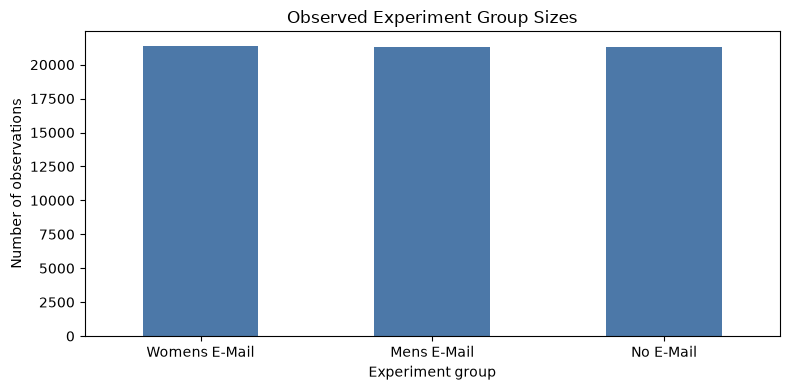

In [5]:
treatment_counts = hillstrom['segment'].value_counts().rename_axis('treatment_group').reset_index(name='observations')
treatment_counts['percentage'] = (treatment_counts['observations'] / len(hillstrom) * 100).round(2)
display(treatment_counts)

ax = treatment_counts.plot.bar(
    x='treatment_group', y='observations', legend=False, color='#4C78A8', figsize=(8, 4)
)
ax.set_title('Observed Experiment Group Sizes')
ax.set_xlabel('Experiment group')
ax.set_ylabel('Number of observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Outcome variable overview

The candidate outcomes are inspected overall, not by treatment group. This avoids estimating or implying treatment effectiveness.

,count,mean,std,min,1%,25%,median,75%,95%,99%,max,zero_count,zero_percentage
visit,64000.0,0.146781,0.353890,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,54606,85.32
conversion,64000.0,0.009031,0.094604,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,63422,99.10
spend,64000.0,1.050908,15.036448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,499.0,63422,99.10



Binary outcome: visit


,visit,count,percentage
0,0,54606,85.32
1,1,9394,14.68



Binary outcome: conversion


,conversion,count,percentage
0,0,63422,99.1
1,1,578,0.9


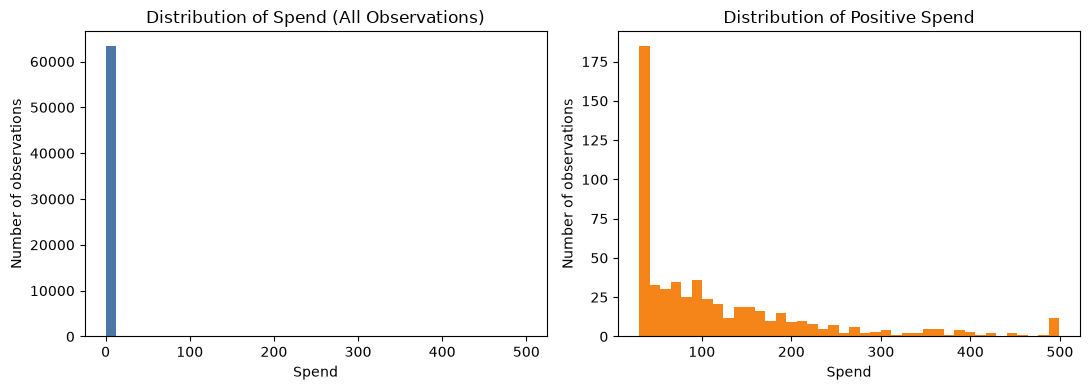

Interpretation: `spend` is zero-inflated; its positive values should be assessed for skewness and outliers in later validation work.


In [6]:
outcome_columns = ['visit', 'conversion', 'spend']
outcome_summary = hillstrom[outcome_columns].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T
outcome_summary = outcome_summary.rename(columns={'50%': 'median'})
outcome_summary['zero_count'] = (hillstrom[outcome_columns] == 0).sum()
outcome_summary['zero_percentage'] = ((hillstrom[outcome_columns] == 0).mean() * 100).round(2)
display(outcome_summary)

for column in ['visit', 'conversion']:
    binary_summary = hillstrom[column].value_counts().sort_index().rename_axis(column).reset_index(name='count')
    binary_summary['percentage'] = (binary_summary['count'] / len(hillstrom) * 100).round(2)
    print(f'\nBinary outcome: {column}')
    display(binary_summary)

positive_spend = hillstrom.loc[hillstrom['spend'] > 0, 'spend']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hillstrom['spend'].plot.hist(bins=40, ax=axes[0], color='#4C78A8')
axes[0].set(title='Distribution of Spend (All Observations)', xlabel='Spend', ylabel='Number of observations')
positive_spend.plot.hist(bins=40, ax=axes[1], color='#F58518')
axes[1].set(title='Distribution of Positive Spend', xlabel='Spend', ylabel='Number of observations')
plt.tight_layout()
plt.show()

print('Interpretation: `spend` is zero-inflated; its positive values should be assessed for skewness and outliers in later validation work.')

## 7. Data-quality profiling

This is an observational profile. No values or rows are removed, corrected, or transformed. An IQR flag below is a screening heuristic, not a determination that any value is erroneous.

In [7]:
missing_cells = int(hillstrom.isna().sum().sum())
exact_duplicate_rows = int(hillstrom.duplicated().sum())
constant_columns = hillstrom.columns[hillstrom.nunique(dropna=False).eq(1)].tolist()

outlier_screen = []
for column in numeric_columns:
    first_quartile, third_quartile = hillstrom[column].quantile([0.25, 0.75])
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    flagged_count = int(((hillstrom[column] < lower_bound) | (hillstrom[column] > upper_bound)).sum())
    outlier_screen.append({
        'variable': column, 'lower_bound': lower_bound, 'upper_bound': upper_bound,
        'iqr_flagged_observations': flagged_count
    })

display(pd.DataFrame(outlier_screen))

quality_summary = pd.DataFrame([
    {'check': 'Missing values', 'observations_affected': missing_cells, 'note': 'Total missing cells across all columns.'},
    {'check': 'Exact duplicate rows', 'observations_affected': exact_duplicate_rows, 'note': 'Rows identical across all observed columns; no identifier exists to confirm duplicate customers.'},
    {'check': 'Duplicate identifiers', 'observations_affected': 'Not assessable', 'note': 'No explicit identifier column is present.'},
    {'check': 'Constant columns', 'observations_affected': len(constant_columns), 'note': ', '.join(constant_columns) if constant_columns else 'None observed.'},
    {'check': 'Treatment labels', 'observations_affected': int(hillstrom['segment'].isna().sum()), 'note': 'Three non-missing observed labels; inspect assignment validity later.'},
])
display(quality_summary)

print('Observed treatment labels:', sorted(hillstrom['segment'].unique()))
print('Observed numeric ranges:')
display(hillstrom[numeric_columns + ['visit', 'conversion']].agg(['min', 'max']).T)

,variable,lower_bound,upper_bound,iqr_flagged_observations
0,recency,-8.50000,19.50000,0
1,history,-326.83625,717.15375,3593
2,spend,0.00000,0.00000,578


,check,observations_affected,note
0,Missing values,0,Total missing cells across all columns.
1,Exact duplicate rows,6562,Rows identical across all observed columns; no...
2,Duplicate identifiers,Not assessable,No explicit identifier column is present.
3,Constant columns,0,None observed.
4,Treatment labels,0,Three non-missing observed labels; inspect ass...


Observed treatment labels: ['Mens E-Mail', 'No E-Mail', 'Womens E-Mail']
Observed numeric ranges:


,min,max
recency,1.00,12.00
history,29.99,3345.93
spend,0.00,499.00
visit,0.00,1.00
conversion,0.00,1.00


## 8. Potential experimentation concerns for later stages

The nearly equal observed group sizes should be formally validated later rather than assumed to demonstrate valid random assignment. Because there is no explicit customer identifier, the 6,562 exact duplicate rows cannot distinguish repeated customers from different customers with identical observed profiles. Later validation should assess assignment integrity, duplicate experimental units if an identifier can be obtained, missingness by treatment, and balance of plausible pre-treatment characteristics.

Both binary outcomes are sparse, and `spend` is zero-inflated with a long positive tail. These distributional features, potential outliers, and the available customer characteristics may matter for later estimand selection, diagnostic checks, and segmentation—not for a treatment conclusion in this stage.

## 9. Data dictionary

Descriptions below are based on observed names and values only. Where the data cannot establish a definition or timing, the interpretation is labelled tentative.

In [8]:
data_dictionary = pd.DataFrame([
    ['recency', 'integer', 'Potential pre-treatment characteristic', '1 to 12', 'Tentatively, a recency measure; unit and timing are not established from the file.'],
    ['history_segment', 'string', 'Potential pre-treatment characteristic', 'Seven labelled monetary bands', 'Tentatively, a binned customer history measure.'],
    ['history', 'float', 'Potential pre-treatment characteristic', '29.99 to 3345.93', 'Tentatively, a customer history monetary measure.'],
    ['mens', 'binary integer', 'Potential pre-treatment characteristic', '0, 1', 'Tentatively, an indicator related to mens merchandise or history.'],
    ['womens', 'binary integer', 'Potential pre-treatment characteristic', '0, 1', 'Tentatively, an indicator related to womens merchandise or history.'],
    ['zip_code', 'string', 'Potential pre-treatment characteristic', 'Rural, Surburban, Urban', 'Geographic category; spelling is retained as observed.'],
    ['newbie', 'binary integer', 'Potential pre-treatment characteristic', '0, 1', 'Tentatively, an indicator of customer newness.'],
    ['channel', 'string', 'Potential pre-treatment characteristic', 'Web, Phone, Multichannel', 'Tentatively, customer channel classification.'],
    ['segment', 'string', 'Likely treatment assignment', 'Mens E-Mail, Womens E-Mail, No E-Mail', 'Likely email experiment group; timing and assignment process are not documented in the file.'],
    ['visit', 'binary integer', 'Likely post-treatment outcome', '0, 1', 'Likely indicator of a visit; exact outcome window is unknown.'],
    ['conversion', 'binary integer', 'Likely post-treatment outcome', '0, 1', 'Likely indicator of conversion; exact definition/window is unknown.'],
    ['spend', 'float', 'Likely post-treatment outcome', '0.00 to 499.00', 'Likely monetary outcome; currency and window are unknown.'],
], columns=['Variable', 'Observed Type', 'Likely Analytical Role', 'Observed Values/Range', 'Description / Interpretation'])
display(data_dictionary)

,Variable,Observed Type,Likely Analytical Role,Observed Values/Range,Description / Interpretation
0,recency,integer,Potential pre-treatment characteristic,1 to 12,"Tentatively, a recency measure; unit and timin..."
1,history_segment,string,Potential pre-treatment characteristic,Seven labelled monetary bands,"Tentatively, a binned customer history measure."
2,history,float,Potential pre-treatment characteristic,29.99 to 3345.93,"Tentatively, a customer history monetary measure."
3,mens,binary integer,Potential pre-treatment characteristic,"0, 1","Tentatively, an indicator related to mens merc..."
4,womens,binary integer,Potential pre-treatment characteristic,"0, 1","Tentatively, an indicator related to womens me..."
5,zip_code,string,Potential pre-treatment characteristic,"Rural, Surburban, Urban",Geographic category; spelling is retained as o...
6,newbie,binary integer,Potential pre-treatment characteristic,"0, 1","Tentatively, an indicator of customer newness."
7,channel,string,Potential pre-treatment characteristic,"Web, Phone, Multichannel","Tentatively, customer channel classification."
8,segment,string,Likely treatment assignment,"Mens E-Mail, Womens E-Mail, No E-Mail",Likely email experiment group; timing and assi...
9,visit,binary integer,Likely post-treatment outcome,"0, 1",Likely indicator of a visit; exact outcome win...


## Stage 01 Findings

The raw dataset contains 64,000 rows and 12 columns. `segment` is the likely treatment variable, with the observed groups `Mens E-Mail`, `Womens E-Mail`, and `No E-Mail`; the latter is the likely control. The likely experimental unit is a customer, but this remains uncertain because no identifier is present.

`visit`, `conversion`, and `spend` are likely primary or secondary outcomes. `recency`, purchase-history fields, merchandise indicators, geography, newness, and channel are plausible customer characteristics, but their definitions and timing are tentative. There are no missing values or constant columns, while 6,562 rows are exact duplicates across the observed fields. The binary outcomes are sparse and `spend` is zero-inflated with a long positive tail.

Stage 02 or Stage 04 should investigate treatment allocation, the nature of duplicated records, baseline balance, outcome distributions/outliers, and whether each candidate characteristic was measured before assignment. No treatment recommendation is made in this notebook.